# Run analysis

Loads a single run's `run.jsonl` + `meta.json` and produces:

1. Metric trajectory over iterations (NDCG@10, Recall@10, Precision@10, ILD@10) with baseline lines for the run's primary and guardrail metrics.
2. Table of best iterations ranked by the run's primary metric, with guardrail-held flag.
3. A utility for diffing the Painless source of any two iterations.

Point `RUN_DIR` at the run you want to inspect.

In [1]:
from __future__ import annotations

import difflib
import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUN_DIR = REPO_ROOT / "runs" / "20260514-002625"

META_KEYS = ("ndcg", "recall", "precision", "ild")
METRIC_COLS = [f"{k}@10" for k in META_KEYS]


def load_run(run_dir: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Load a run's JSONL + meta.json.

    Args:
        run_dir: A directory containing `run.jsonl` and `meta.json`.

    Returns:
        A `(records, meta)` tuple where `records` is one row per iteration with
        metric columns flattened (e.g. `ndcg@10`) alongside the raw fields, and
        `meta` is the parsed `meta.json` payload.
    """
    meta = json.loads((run_dir / "meta.json").read_text())
    rows: list[dict[str, Any]] = []
    with (run_dir / "run.jsonl").open() as fh:
        for line in fh:
            rec = json.loads(line)
            metrics = rec.get("metrics") or {}
            rows.append({**rec, **{k: metrics.get(k) for k in METRIC_COLS}})
    df = pd.DataFrame(rows).sort_values("iter").reset_index(drop=True)
    return df, meta


df, meta = load_run(RUN_DIR)
print(f"run: {RUN_DIR.name}  objective: {meta['objective']}  iters: {len(df)}")
df[["iter", "parent_iter", *METRIC_COLS, "compile_error"]]

run: 20260514-002625  objective: ndcg  iters: 4


,iter,parent_iter,ndcg@10,recall@10,precision@10,ild@10,compile_error
0,0,NaN,0.040140,0.063900,0.013590,0.243103,None
1,1,0.0,0.034836,0.053012,0.011207,0.285163,None
2,2,0.0,0.034836,0.053012,0.011207,0.285133,None
3,3,1.0,0.071366,0.098999,0.020183,0.417632,None


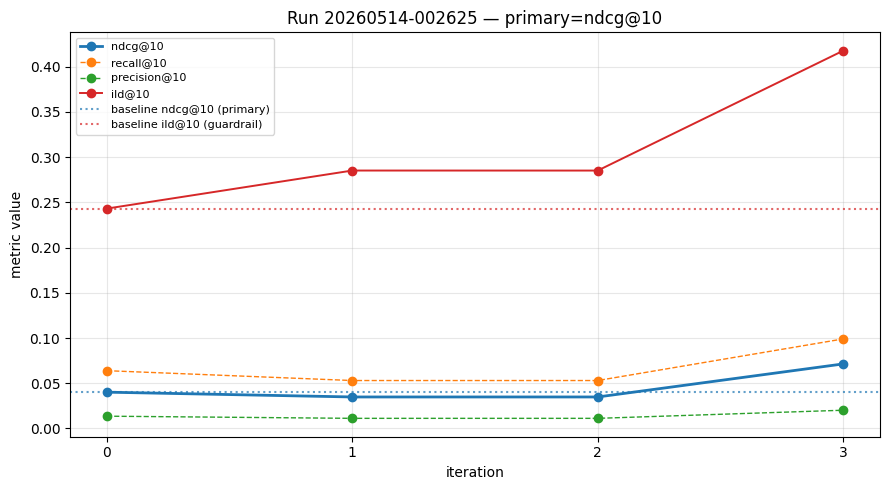

In [2]:
def _objective_keys(meta: dict[str, Any]) -> tuple[str, str]:
    """Return `(primary_key, guardrail_key)` like `("ndcg@10", "ild@10")`."""
    primary = f"{meta['objective']}@10"
    guardrail = "ild@10" if primary == "ndcg@10" else "ndcg@10"
    return primary, guardrail


def plot_trajectory(df: pd.DataFrame, meta: dict[str, Any]) -> None:
    """Plot all four metrics over iterations, baselines, and guardrail breaches."""
    primary, guardrail = _objective_keys(meta)
    baseline = meta["baseline_metrics"]

    fig, ax = plt.subplots(figsize=(9, 5))
    for col in METRIC_COLS:
        style = "-" if col in (primary, guardrail) else "--"
        width = 2.0 if col == primary else 1.4 if col == guardrail else 1.0
        ax.plot(df["iter"], df[col], style, linewidth=width, marker="o", label=col)

    ax.axhline(baseline[primary], linestyle=":", color="C0", alpha=0.7,
               label=f"baseline {primary} (primary)")
    ax.axhline(baseline[guardrail], linestyle=":", color="C3", alpha=0.7,
               label=f"baseline {guardrail} (guardrail)")

    breaches = df[df[guardrail] < baseline[guardrail]]
    if not breaches.empty:
        ax.scatter(breaches["iter"], breaches[guardrail], s=140,
                   facecolors="none", edgecolors="red", linewidths=2,
                   label=f"guardrail breach ({len(breaches)})")

    ax.set_xlabel("iteration")
    ax.set_ylabel("metric value")
    ax.set_title(f"Run {RUN_DIR.name} — primary={primary}")
    ax.set_xticks(df["iter"])
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_trajectory(df, meta)

In [3]:
def best_iterations(df: pd.DataFrame, meta: dict[str, Any], top: int = 5) -> pd.DataFrame:
    """Top iterations ranked by the run's primary metric.

    Args:
        df: Run records from `load_run`.
        meta: Parsed `meta.json`.
        top: Maximum number of rows to return.

    Returns:
        A DataFrame with columns `iter`, primary metric, guardrail metric,
        `guardrail_held`, `rationale`, and `parent_iter`.
    """
    primary, guardrail = _objective_keys(meta)
    guardrail_floor = meta["baseline_metrics"][guardrail]
    scored = df.dropna(subset=[primary]).copy()
    scored["guardrail_held"] = scored[guardrail] >= guardrail_floor
    scored = scored.sort_values(primary, ascending=False).head(top)
    return scored[[
        "iter", primary, guardrail, "guardrail_held", "llm_rationale", "parent_iter",
    ]].rename(columns={"llm_rationale": "rationale"}).reset_index(drop=True)


best_iterations(df, meta)

,iter,ndcg@10,ild@10,guardrail_held,rationale,parent_iter
0,3,0.071366,0.417632,True,Add a weak log popularityScore prior to contin...,1.0
1,0,0.040140,0.243103,True,NaN,NaN
2,1,0.034836,0.285163,True,First candidate: replace baseline-style quanti...,0.0
3,2,0.034836,0.285133,True,Recreate the reference/baseline scoring semant...,0.0


In [4]:
def _iter_sources(run_dir: Path, iter_idx: int) -> dict[str, str]:
    """Return `{filename: source}` for an iteration's Painless files."""
    iter_dir = run_dir / f"iter_{iter_idx:03d}"
    if not iter_dir.is_dir():
        raise FileNotFoundError(iter_dir)
    return {p.name: p.read_text() for p in sorted(iter_dir.glob("*.painless"))}


def diff_iterations(run_dir: Path, a: int, b: int) -> None:
    """Print a unified diff of every Painless file shared (or new) between two iterations.

    Args:
        run_dir: The run directory containing `iter_NNN/` subdirs.
        a: The "from" iteration index.
        b: The "to" iteration index.
    """
    left = _iter_sources(run_dir, a)
    right = _iter_sources(run_dir, b)
    for name in sorted(left.keys() | right.keys()):
        left_lines = left.get(name, "").splitlines(keepends=True)
        right_lines = right.get(name, "").splitlines(keepends=True)
        diff = list(difflib.unified_diff(
            left_lines, right_lines,
            fromfile=f"iter_{a:03d}/{name}",
            tofile=f"iter_{b:03d}/{name}",
            n=3,
        ))
        if not diff:
            print(f"== {name}: identical ==\n")
            continue
        print("".join(diff))
        print()


diff_iterations(RUN_DIR, 0, int(meta["summary"]["best_iter"]))

--- iter_000/query.painless
+++ iter_003/query.painless
@@ -1,24 +1,22 @@
-// script_score requires a non-negative return; bail out when the doc has
-// no indexed vector rather than letting cosineSimilarity throw.
 if (doc['item_vector'].size() == 0) {
-  return 0.0;
+    return 0.0;
 }
 
-// params.user_vector is a 10x32 List<List<Double>>. Mean-pool into a
-// single 32-d ArrayList<Double> — cosineSimilarity's vector argument is
-// List<Number>; the double[] overload referenced in older notes does
-// not exist in 8.13 and triggers a class_cast_exception at compile.
-List userVectors = params.user_vector;
-int n = userVectors.size();
-int dim = ((List) userVectors.get(0)).size();
-ArrayList pooled = new ArrayList();
-for (int j = 0; j < dim; j++) {
-  double sum = 0.0;
-  for (int i = 0; i < n; i++) {
-    sum += ((Number) ((List) userVectors.get(i)).get(j)).doubleValue();
-  }
-  pooled.add(sum / n);
+double best = -2.0;
+for (int i = 0; i < params.user_vector.size(); i++) {
+    